# Reconstruct Stokes profile from ERA5 wave output
- Author: Muxin Hu
- created time: 12.04.2026
- modified time: 13.04.2026

The vertical structure of the Stokes drift is reconstructed following the parameterization of **Breivik et al. (2014)**, which approximates the Stokes drift profile in terms of two wave parameters: the Stokes transport ($\mathbf V_s$) and the surface Stokes drift velocity ($\mathbf u_s(0)$). 

**The Stokes drift velocity as a function of depth $z$** is given by:
\begin{equation}
    \mathbf {u}_s(z)=\mathbf {u}_s(0)\frac{e^{2k_ez}}{1-Ck_ez} \tag{1}
\end{equation}
where:
\begin{equation}
    C\approx 8 \tag{2}
\end{equation}
and the **inverse depth scale $k_e$** is defined as
\begin{equation}
    k_e =\frac{\mathbf {u}_s(0)[e^{1/4}E_1(1/4)]}{8\mathbf V_s},\quad \text{with}\quad e^{1/4}E_1(1/4)\approx 1.34. \tag{3}
\end{equation}
Here, $E_1$ denotes the exponential integral. The **Stokes transport ($\mathbf V_s$) can be approximated from bulk wave parameters** as:
\begin{equation}
    \mathbf{V_s}\approx \frac{\pi H_s^2}{8 \overline{T}} \hat{\mathbf {k}}_s \tag{4}
\end{equation}
Where $H_s$ is the significant wave height, $\overline{T}$ is the mean wave period, and $\hat{\mathbf {k}}_s$ is the unit vector in the mean wave propagation direction. **Breivil et al. (2014) suggests that it is better to estimate the transport direction from the mean wave direction raher than from the surface Stokes advection**, as the Stokes transport is more influenced by the low-frequency wave (i.e., swells) in principle. The mean wave direction represents bulk spectrum, and is much closer to transport direction. Evidence shows mean wave direction differing from transport direction only by ~2 degree on average.

In [1]:
import xarray as xr
import numpy as np
import pyicon as pyic
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm
import matplotlib.ticker as ticker
import matplotlib.gridspec as gridspec
import cmocean as cmo
import cartopy.crs as ccrs
import cartopy.feature as cfeature
%matplotlib inline

----Start loading pyicon.
Loading default parameters from /home/m/m301254/Download/pyicon/pyicon/params_default.json.


ERROR 1: PROJ: proj_create_from_database: Open of /home/m/m301254/.conda/envs/env02_waves/share/proj failed


----Start loading pyicon.
----Pyicon was loaded successfully.
----Pyicon was loaded successfully.


## Read Data

In [2]:
# read data
wave_globe = xr.open_dataset("/work/mh0033/m301254/proj_surfwave/processed_data/era5/era5_SurfWaves_global_1979-2025.grib",engine="cfgrib")

In [4]:
wave_globe

<xarray.Dataset> Size: 6GB
Dimensions:     (time: 564, latitude: 361, longitude: 720)
Coordinates:
  * time        (time) datetime64[ns] 5kB 1979-01-01 1979-02-01 ... 2025-12-01
  * latitude    (latitude) float64 3kB 90.0 89.5 89.0 88.5 ... -89.0 -89.5 -90.0
  * longitude   (longitude) float64 6kB 0.0 0.5 1.0 1.5 ... 358.5 359.0 359.5
    number      int64 8B ...
    step        timedelta64[ns] 8B ...
    meanSea     float64 8B ...
    valid_time  (time) datetime64[ns] 5kB ...
Data variables:
    mwd         (time, latitude, longitude) float32 586MB ...
    mwp         (time, latitude, longitude) float32 586MB ...
    swh         (time, latitude, longitude) float32 586MB ...
    mdts        (time, latitude, longitude) float32 586MB ...
    mdww        (time, latitude, longitude) float32 586MB ...
    mpts        (time, latitude, longitude) float32 586MB ...
    mpww        (time, latitude, longitude) float32 586MB ...
    shts        (time, latitude, longitude) float32 586MB ...
    shww        (time, latitude, longitude) float32 586MB ...
    ust         (time, latitude, longitude) float32 586MB ...
    vst         (time, latitude, longitude) float32 586MB ...
Attributes:
    GRIB_edition:            1
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-04-13T21:21 GRIB to CDM+CF via cfgrib-0.9.1...

## Estimate: Stokes transport
- Formula: $$\mathbf{V_s}\approx \frac{\pi H_s^2}{8 \overline{T}} \hat{\mathbf {k}}_s$$
    - using: mean wave significant height, direction, and period, either from:
        - **Separated in wind wave and total swells**
            - Treating each kind as monochromatic wave with narrow spectrum band
            - Two wave systems exist, can account for opposing Stokes transports from two groups. More consistent
        - **Combined wind waves and swell**
            - single-direction approximation
    - mean wave direction is a better directional proxy for transport than surface Stokes drift (Breivik et al., 2014)

In [3]:
# Estimate the Stokes transport (unit: m^2/s)
def estimate_stokes_transport(Hs, T, theta_from_deg):
    """
    theta_drom_deg: the raw ERA5 data are degrees that waves are coming FROM, 
    so zero means 'coming from the north' and 90 'coming from the east'.
    """
    # convert coming from to propagating toward
    theta = np.deg2rad((theta_from_deg + 180) % 360)

    Vs_mag = np.pi * Hs**2 / (8 * T)
    Vs_u = Vs_mag * np.sin(theta) # eastward
    Vs_v = Vs_mag * np.cos(theta) # northward

    return Vs_u, Vs_v

# Separately estimated from wind wave and swell
# Wind wave (ww)
Vst_u_ww, Vst_v_ww = estimate_stokes_transport(wave_globe["shww"], wave_globe["mpww"], wave_globe["mdww"])
# Total Swells (ts)
Vst_u_ts, Vst_v_ts = estimate_stokes_transport(wave_globe["shts"], wave_globe["mpts"], wave_globe["mdts"])
# combine
Vst_u = Vst_u_ww + Vst_u_ts
Vst_v = Vst_v_ww + Vst_v_ts

# directly estimated from mean wave direction/period/height
Vst_u_direct, Vst_v_direct = estimate_stokes_transport(wave_globe["swh"], wave_globe["mwp"], wave_globe["mwd"])

## inverse depth scale: $k_e$

- Formula: $k_e =\frac{\mathbf {u}_s(0)[e^{1/4}E_1(1/4)]}{8\mathbf V_s},\quad \text{with}\quad e^{1/4}E_1(1/4)\approx 1.34 $
- Steps:
    1. **Compute surface Stokes drift magnitude and unit direction**: $∣u_s​(0)∣=\sqrt{u_{st}^2​+v_{st}^2​}
​$, $\hat e = \frac{u_s(0)}{∣u_s​(0)∣}$
    2. **Project transport onto surface Stokes drift direction**: $\mathbf V_{st}'=\mathbf V_{st}\cdot \hat e$, to ensure consistency between transport magnitude and profile direction
        - in numerical way: $\mathbf V_{st}' = V_{s,u}e_u + V_{s,v}e_v$, where $\mathbf V_{st}'$ becomes a **scalar quantity** in the same direction as $\mathbf {u}_s(0)$
    3. **Compute inverse depth scale**: $k_e \approx \frac{1.34∣u_s​(0)∣}{8\mathbf V_{st}'}$

In [4]:
# compute surface stokes drift magnitude and unit direction
ust = wave_globe["ust"]
vst = wave_globe["vst"]
us_mag = np.sqrt(ust**2 + vst**2)
# avoid division by zero
eps = 1e-12
e_u = ust / (us_mag + eps)
e_v = vst / (us_mag + eps)

### For $\mathbf V_s$ from combined wave

In [5]:
# project transport onto surface Stokes drift direction
V_parallel_direct = Vst_u_direct * e_u + Vst_v_direct * e_v # ensure the direction is the correction of surface Stokes drift velocity

In [6]:
# compute the inverse depth scale
ke_direct = 1.34 * us_mag / (8 * (V_parallel_direct + eps))

### For $\mathbf V_s$ from separated waves (ww, ts)

In [7]:
V_parallel_total = Vst_u * e_u + Vst_v * e_v
ke_total = 1.34 * us_mag / (8 * (V_parallel_total + eps))

In [24]:
print(ke_direct.shape)
print(np.nanmean(ke_direct.values))
print(np.nanmean(ke_total.values))

(564, 361, 720)
0.060055852
0.15201841


### Climatological field of near-surface e-folding depth ($1/2k_e$)

In [8]:
depth_direct = 1 / (2 * ke_direct)
depth_total = 1 / (2 * ke_total)

# climatologies: annual
depth_direct_clim = depth_direct.mean(dim="time")
depth_total_clim = depth_total.mean(dim="time")

# climatologies: JJA and DJF
depth_direct_clim_JJA = depth_direct.sel(time=depth_direct.time.dt.season == "JJA", drop=True).mean(dim="time")
depth_direct_clim_DJF = depth_direct.sel(time=depth_direct.time.dt.season == "DJF", drop=True).mean(dim="time")

depth_total_clim_JJA = depth_total.sel(time=depth_total.time.dt.season == "JJA", drop=True).mean(dim="time")
depth_total_clim_JJA = depth_total.sel(time=depth_total.time.dt.season == "JJA", drop=True).mean(dim="time")
depth_total_clim_DJF = depth_total.sel(time=depth_total.time.dt.season == "DJF", drop=True).mean(dim="time")
depth_total_clim_DJF = depth_total.sel(time=depth_total.time.dt.season == "DJF", drop=True).mean(dim="time")

In [9]:
def plot_divergence_panel(ax, da, title, vmin, vmax, cmap="RdBu_r"):
    """
    Plot a single convergence panel
    
    Parameters:
    -------------
    ax: matplotlib axix
    da: 2D dataArray (lat, lon)
    title: subplot title
    """
    im = ax.pcolormesh(da.longitude, da.latitude, da, 
                       cmap=cmap, vmin=vmin, vmax=vmax, 
                       shading="auto",
                       transform=ccrs.PlateCarree())
    ax.coastlines(linewidth=0.7)
    ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=0)
    ax.set_title(title, loc="left", fontsize=14)
    # remove the gridline lables on the right and top
    gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray',
                  alpha=0.5, linestyle='--')
    gl.right_labels = False
    gl.top_labels = False
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    return im

#### Annual mean climatologies

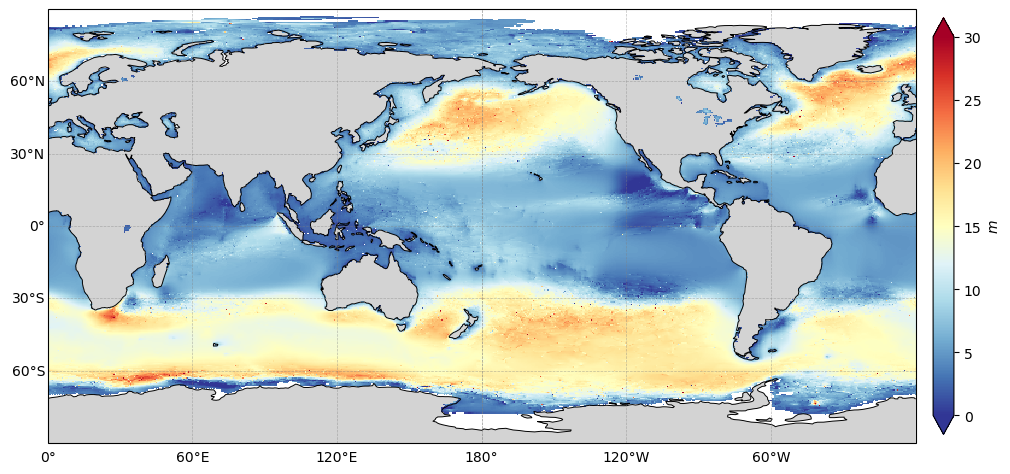

In [15]:
fig, ax = plt.subplots(figsize=(10, 6),
                       subplot_kw={"projection": ccrs.PlateCarree(central_longitude=180)},
                       constrained_layout=True)
im1 = plot_divergence_panel(ax, depth_total_clim, r"Near-surface e-folding depth ($1/2k_e$): separately estimation", 0, 30, cmap="RdYlBu_r")
cbar = fig.colorbar(im1, ax=ax,orientation="vertical", label=f"$m$", pad = 0.02, fraction=0.024, extend="both")
save_path = "/home/m/m301254/project_surfwaves/figs/era5_Stokes_transport"
plt.savefig(f"{save_path}/Estimated_efolding_depth_for_Stokes_drift_profile_separate_ww_ts.png", dpi=150 ,bbox_inches="tight")

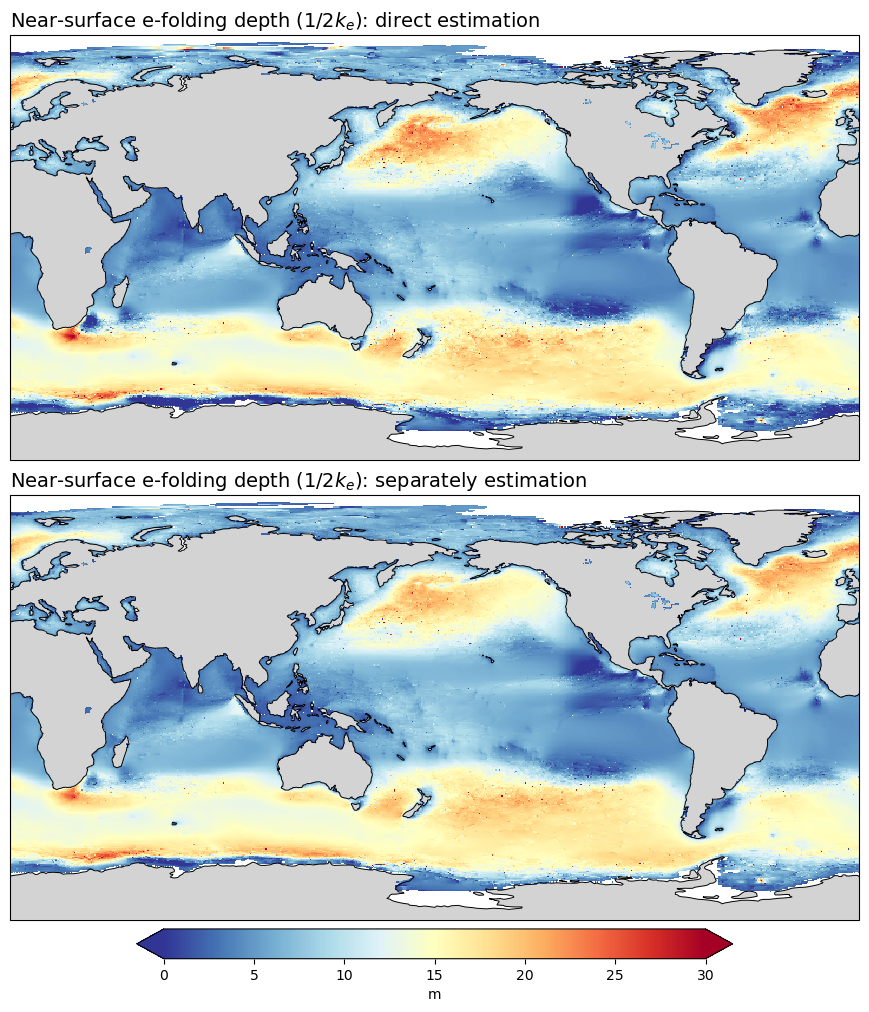

In [45]:
fig, axes = plt.subplots(2,1, figsize=(12, 10),
                         subplot_kw={"projection": ccrs.PlateCarree(central_longitude=180)},
                         constrained_layout=True)

im0 = plot_divergence_panel(axes[0], depth_direct_clim, r"Near-surface e-folding depth ($1/2k_e$): direct estimation", 0, 30, cmap="RdYlBu_r")
im1 = plot_divergence_panel(axes[1], depth_total_clim, r"Near-surface e-folding depth ($1/2k_e$): separately estimation", 0, 30, cmap="RdYlBu_r")

cbar1 = fig.colorbar(im1, ax=axes[1], orientation="horizontal", pad=0.02, shrink=0.5, extend="both")
cbar1.set_label("m")

save_path = "/home/m/m301254/project_surfwaves/figs/era5_Stokes_transport"
plt.savefig(f"{save_path}/Estimated_efolding_depth_for_Stokes_drift_profile.png", dpi=150 ,bbox_inches="tight")

e-folding depth scale: $\delta \sim 1/2k_e$ provides a measure of the near-surface penetration of the Stokes drift, indicatinf **how deep the core influence reaches**

#### Seasonal mean climatologies

Text(0.5, 0.98, 'Estimated near-surface e-folding depth for Stokes drift profile')

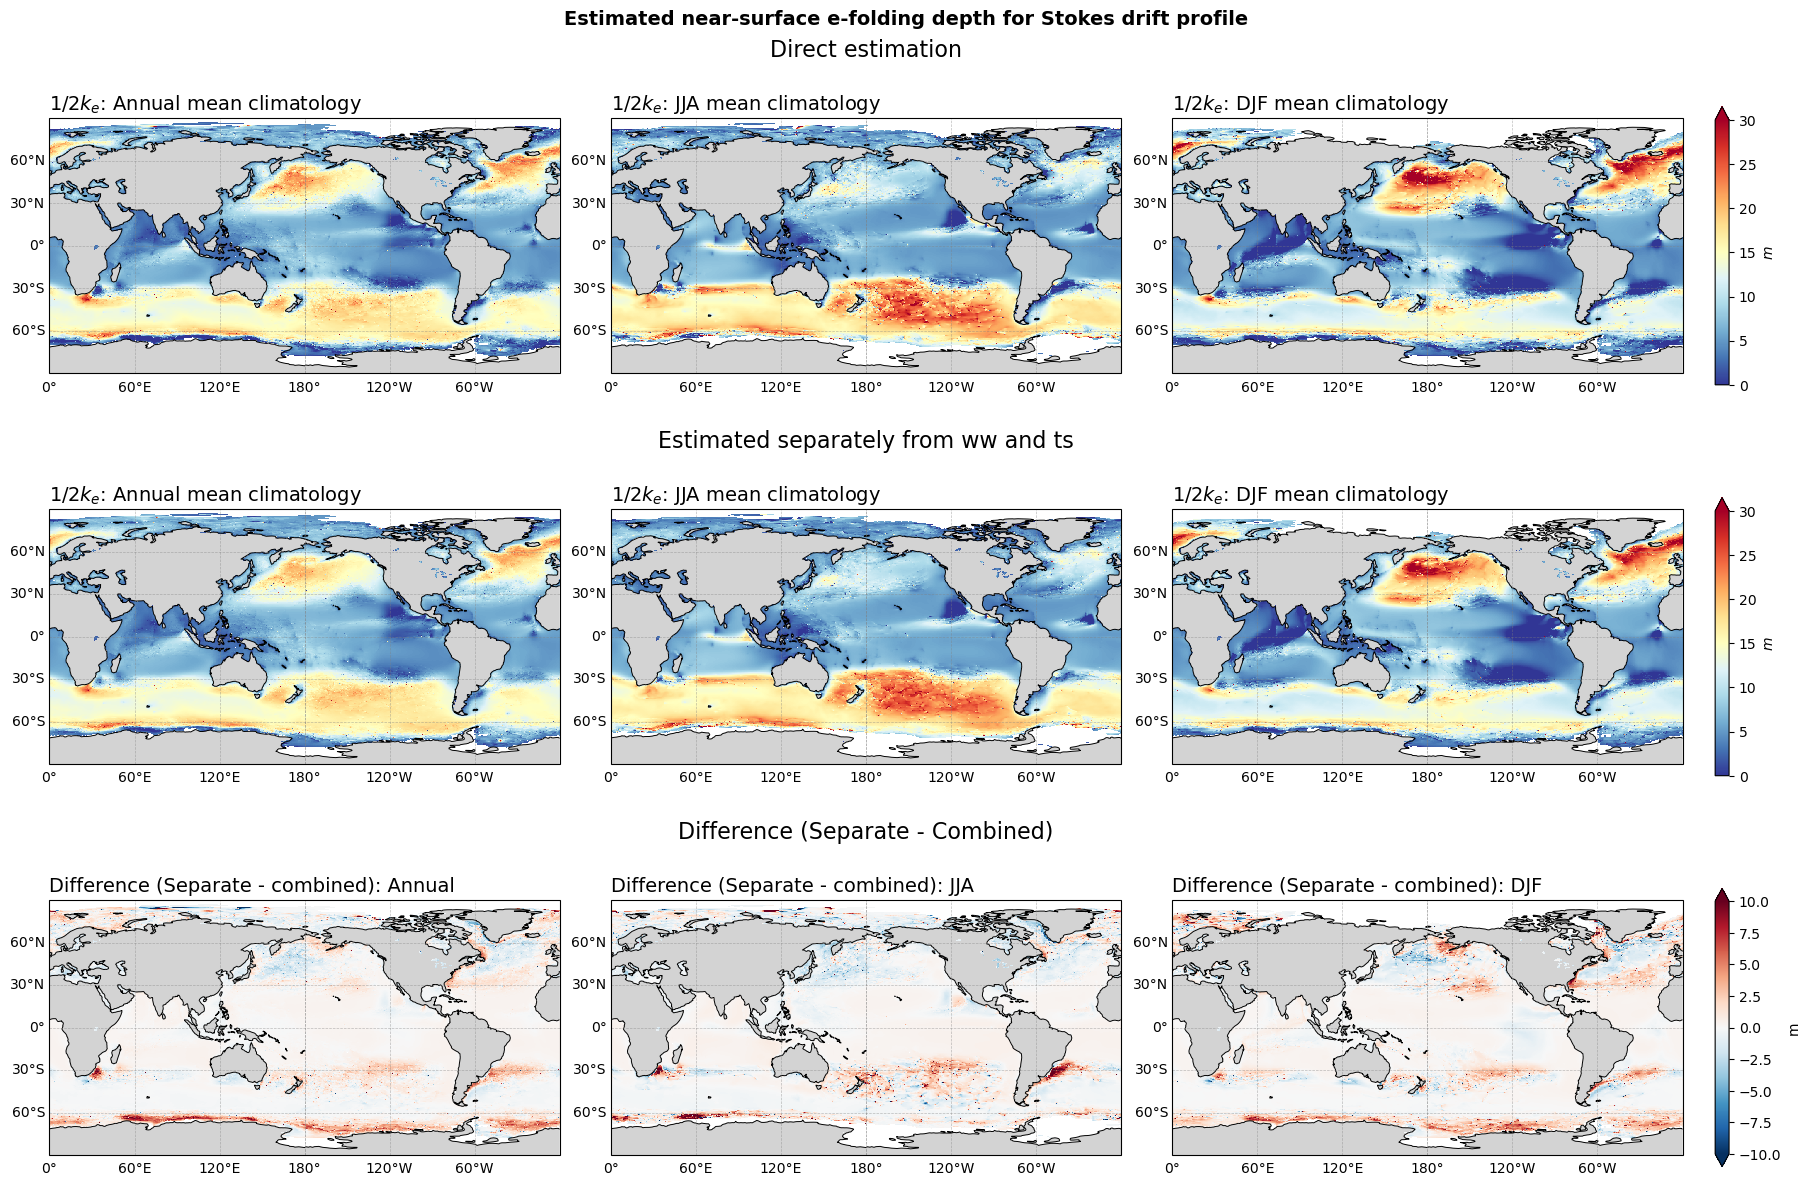

In [19]:
fig, axes = plt.subplots(3, 3, figsize=(18, 12),
                         subplot_kw={"projection": ccrs.PlateCarree(central_longitude=180)},
                         constrained_layout=True)

# Direct estimation
im0 = plot_divergence_panel(axes[0,0], depth_direct_clim, r"$1/2k_e$: Annual mean climatology", 0, 30, cmap="RdYlBu_r")
plot_divergence_panel(axes[0,1], depth_direct_clim_JJA, r"$1/2k_e$: JJA mean climatology", 0, 30, cmap="RdYlBu_r")
plot_divergence_panel(axes[0,2], depth_direct_clim_DJF, r"$1/2k_e$: DJF mean climatology", 0, 30, cmap="RdYlBu_r")
cbar1 = fig.colorbar(im0, ax=axes[0,:], orientation="vertical", pad=0.02, shrink=0.8, extend="max")
cbar1.set_label("$m$")
axes[0,1].set_title("Direct estimation\n\n" + axes[0,1].get_title(), fontsize=16)

# Estimated separatedly from ww and ts
im1 = plot_divergence_panel(axes[1,0], depth_total_clim, r"$1/2k_e$: Annual mean climatology", 0, 30, cmap="RdYlBu_r")
plot_divergence_panel(axes[1,1], depth_total_clim_JJA, r"$1/2k_e$: JJA mean climatology", 0, 30, cmap="RdYlBu_r")
plot_divergence_panel(axes[1,2], depth_total_clim_DJF, r"$1/2k_e$: DJF mean climatology", 0, 30, cmap="RdYlBu_r")
cbar2 = fig.colorbar(im1, ax=axes[1,:], orientation="vertical", pad=0.02, shrink=0.8, extend="max")
cbar2.set_label("$m$")
axes[1,1].set_title("Estimated separately from ww and ts\n\n" + axes[1,1].get_title(), fontsize=16)

# Difference: Separate - combined
diff_clim = depth_total_clim - depth_direct_clim
diff_JJA  = depth_total_clim_JJA - depth_direct_clim_JJA
diff_DJF  = depth_total_clim_DJF - depth_direct_clim_DJF

vmax = 10 # unit: m
vmin = -vmax

im2 = plot_divergence_panel(axes[2,0], diff_clim, "Difference (Separate - combined): Annual", vmin, vmax)
plot_divergence_panel(axes[2,1], diff_JJA, "Difference (Separate - combined): JJA", vmin, vmax)
plot_divergence_panel(axes[2,2], diff_DJF, "Difference (Separate - combined): DJF", vmin, vmax)
cbar3 = fig.colorbar(im2, ax=axes[2,:], orientation="vertical", pad=0.02, shrink=0.8, extend="both")
cbar3.set_label("m")
axes[2,1].set_title("Difference (Separate - Combined)\n\n" + axes[2,1].get_title(), fontsize=16)

fig.suptitle(
    "Estimated near-surface e-folding depth for Stokes drift profile",
    fontsize=14, fontweight="bold"
)

#### Time-series of $1/2k_e$ over tropical region

[-88.  -88.5 -89.  -89.5]
[357.5 358.  358.5 359. ]


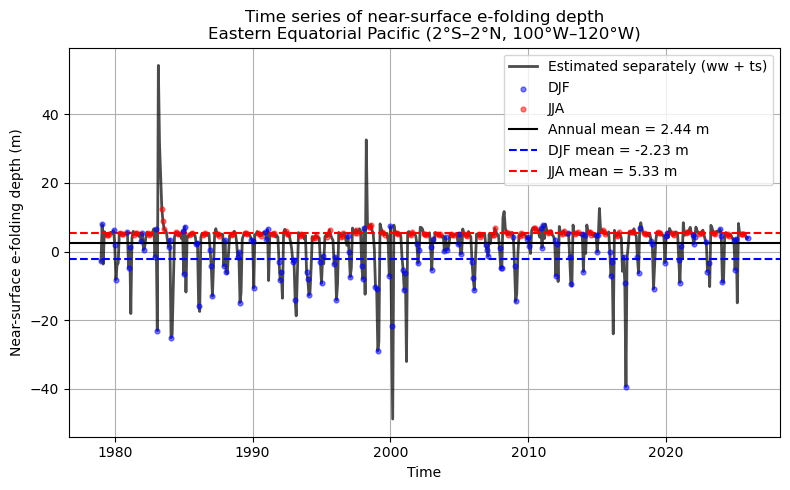

In [36]:
# select regions
print(depth_total.latitude.values[-5:-1])
print(depth_total.longitude.values[-5:-1])

# choose the Eastern equatorial Pacific region
depth_total_reg = depth_total.sel(latitude=slice(2, -2), longitude=slice(240, 260))
depth_direct_reg = depth_direct.sel(latitude=slice(2, -2), longitude=slice(240, 260))

# area average
depth_total_reg_mean = depth_total_reg.mean(dim=["latitude", "longitude"])
depth_direct_reg_mean = depth_direct_reg.mean(dim=["latitude", "longitude"])

# add seasonal coordinate
depth_direct_reg_mean = depth_direct_reg_mean.assign_coords(
    season=depth_direct_reg_mean["time"].dt.season)

# calculate time means
depth_direct_DJF = depth_direct_reg_mean.where(depth_direct_reg_mean.season == "DJF", drop=True).mean()
depth_direct_JJA = depth_direct_reg_mean.where(depth_direct_reg_mean.season == "JJA", drop=True).mean()
depth_direct_ANN = depth_direct_reg_mean.mean()

# time series plot
time = depth_direct_reg_mean.time.values
values = depth_direct_reg_mean.values
seasons = depth_direct_reg_mean.season.values

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(time, values, color="black", alpha=0.7, linewidth=2.0, label="Estimated separately (ww + ts)") # main
mask_djf = seasons == "DJF"
ax.scatter(time[mask_djf], values[mask_djf], color="blue", alpha=0.5, s=12, label="DJF", zorder=3) # DJF
mask_jja = seasons == "JJA"
ax.scatter(time[mask_jja], values[mask_jja], color="red", alpha=0.5, s=12, label="JJA", zorder=3) # JJA

# horizontal mean lines
ax.axhline(depth_direct_ANN, color="black", linestyle="-", linewidth=1.5, label=f"Annual mean = {depth_direct_ANN.values:.2f} m")
ax.axhline(depth_direct_DJF, color="blue", linestyle="--", linewidth=1.5, label=f"DJF mean = {depth_direct_DJF.values:.2f} m")
ax.axhline(depth_direct_JJA, color="red", linestyle="--", linewidth=1.5, label=f"JJA mean = {depth_direct_JJA.values:.2f} m")

# labels & formatting
ax.set_xlabel("Time")
ax.set_ylabel("Near-surface e-folding depth (m)")
ax.set_title(
    "Time series of near-surface e-folding depth\n"
    "Eastern Equatorial Pacific (2°S–2°N, 100°W–120°W)")

ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()

## Reconstruct Stokes drift profile
- Original formula in Breivik et al. (2014): $\mathbf {u}_s(z)=\mathbf {u}_s(0)\frac{e^{2k_ez}}{1-Ck_ez}$
- **Modified**: $\mathbf {u}_s(z)=\hat e |\mathbf {u}_s(0)|\frac{e^{2k_ez}}{1-Ck_ez}$